## Text to Vectore techniques:

One hot encoding

Bag of words

TF - IDF

Word2Vec

Avg word2vec

# One hot encoding

### The Advantages of One Hot Encoding
We can Easily make the one hot encoding using 
- Scikit-learn, 
- in pandas we can use get_dummies, 
- in pytorch we can use one_hot, 
- in tensorflow we can use 

### The Disadvantages of One Hot Encoding
- It Create Sparse Vectors, which are not efficient for large datasets
- It is not scale invariant
- Which leads to high dimensionality and Overfitting
- It may have the Different shape of the Input for the ML Algorithm.
- No semantic Information captured
- It  does is work when the word is out of Vocabulary

In [ ]:
# One hot encoding
from torch import Size
D1 = "The food is good"
D2 = "The food is bad"
D3 = "The food average"

unique_words = ["The", "food", "is", "good", "bad", "average"]

D1_vector = [[1, 0, 0, 0, 0, 0], # 1 represents The which is the first word in unique_words
             [0, 1, 0, 0, 0, 0], # 1 represents food which is the second word in unique_words
             [0, 0, 1, 0, 0, 0], # 1 represents is which is the third word in unique_words
             [0, 0, 0, 1, 0, 0]] # 1 represents good which is the fourth word in unique_words

D2_vector = [[1, 0, 0, 0, 1, 0], # 1 represents The which is the first word in unique_words
             [0, 1, 0, 0, 0, 0], # 1 represents food which is the second word in unique_words
             [0, 0, 1, 0, 0, 0], # 1 represents is which is the third word in unique_words
             [0, 0, 0, 0, 1, 0]] # 1 represents bad which is the fifth word in unique_words

D3_vector = [[1, 0, 0, 0, 0, 0], # 1 represents The which is the first word in unique_words
             [0, 1, 0, 0, 0, 0], # 1 represents food which is the second word in unique_words
             [0, 0, 0, 0, 0, 1]] # 1 represents average which is the sixth word in unique_words

# See the shape of the vectors
import numpy as np

D1_vector = np.array(D1_vector)
D2_vector = np.array(D2_vector)
D3_vector = np.array(D3_vector)

print("Shape of D1_vector:", D1_vector.shape)
print("Shape of D2_vector:", D2_vector.shape)
print("Shape of D3_vector:", D3_vector.shape)

Shape of D1_vector: (4, 6)
Shape of D2_vector: (4, 6)
Shape of D3_vector: (3, 6)


In [2]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

data = {
    'Employee id': [10, 20, 15, 25, 30],
    'Gender': ['M', 'F', 'F', 'M', 'F'],
    'Remarks': ['Good', 'Nice', 'Good', 'Great', 'Nice']
}

df = pd.DataFrame(data)
df


,Employee id,Gender,Remarks
0,10,M,Good
1,20,F,Nice
2,15,F,Good
3,25,M,Great
4,30,F,Nice


In [5]:
# Use pd.get_dummies() to one-hot encode the categorical columns
df_pandas_encoded = pd.get_dummies(df, columns=['Gender', 'Remarks'])
df_pandas_encoded

,Employee id,Gender_F,Gender_M,Remarks_Good,Remarks_Great,Remarks_Nice
0,10,False,True,True,False,False
1,20,True,False,False,False,True
2,15,True,False,True,False,False
3,25,False,True,False,True,False
4,30,True,False,False,False,True


In [20]:
encoder = OneHotEncoder()
categorical_columns = ['Gender', 'Remarks']
print(encoder)
one_hot_encoded = encoder.fit_transform(df[categorical_columns])

encoded_array = one_hot_encoded.toarray()

encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(['Gender', 'Remarks']),
    index=df['Employee id']
)

print(encoded_df)

OneHotEncoder()
             Gender_F  Gender_M  Remarks_Good  Remarks_Great  Remarks_Nice
Employee id                                                               
10                0.0       1.0           1.0            0.0           0.0
20                1.0       0.0           0.0            0.0           1.0
15                1.0       0.0           1.0            0.0           0.0
25                0.0       1.0           0.0            1.0           0.0
30                1.0       0.0           0.0            0.0           1.0


In [26]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

data = {'Employee id': [10, 20, 15, 25, 30],
        'Gender': ['M', 'F', 'F', 'M', 'F'],
        'Remarks': ['Good', 'Nice', 'Good', 'Great', 'Nice'],
        }
df = pd.DataFrame(data)
print(df)

categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
encoder = OneHotEncoder(sparse_output=False)

one_hot_encoded = encoder.fit_transform(df[categorical_columns])

one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_columns))

df_encoded = pd.concat([df, one_hot_df], axis=1)

df_encoded = df_encoded.drop(categorical_columns, axis=1)
df_encoded

   Employee id Gender Remarks
0           10      M    Good
1           20      F    Nice
2           15      F    Good
3           25      M   Great
4           30      F    Nice


C:\Users\yogeshkannah\AppData\Local\Temp\ipykernel_14048\3700264430.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns.tolist()


,Employee id,Gender_F,Gender_M,Remarks_Good,Remarks_Great,Remarks_Nice
0,10,0.0,1.0,1.0,0.0,0.0
1,20,1.0,0.0,0.0,0.0,1.0
2,15,1.0,0.0,1.0,0.0,0.0
3,25,0.0,1.0,0.0,1.0,0.0
4,30,1.0,0.0,0.0,0.0,1.0


# Bag of Words

Binary BOW 
- {1 or 0}

BOW
- {1 or 2 or 3 or ...} (based on the frequency of the word in the sentence)

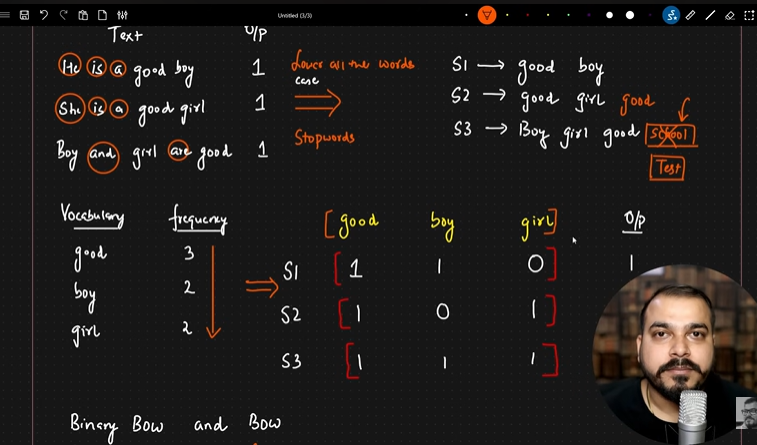

## The Advantages of Bag of Words
- Fixed size Input in ML Alorithms
- simple and intuitive

## The Disadvantages of Bag of Words
- Spare Matrix still there
- The Irragular Ordering of the words is not preserved
- It does is work when the word is out of Vocabulary
- Semantic Information is still not captured 

#  TF - IDF (Term Frequency - Inverse Document Frequency)

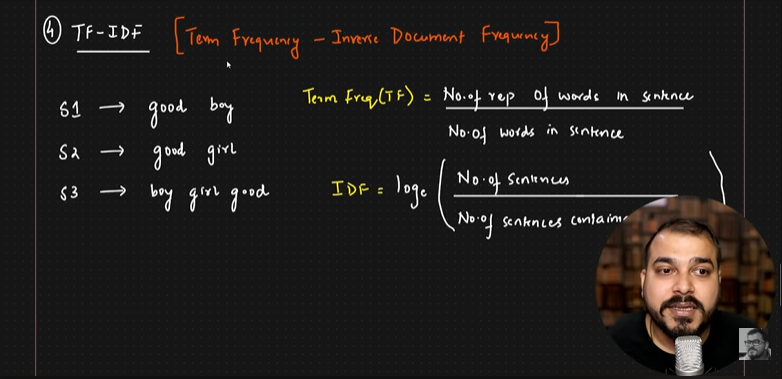

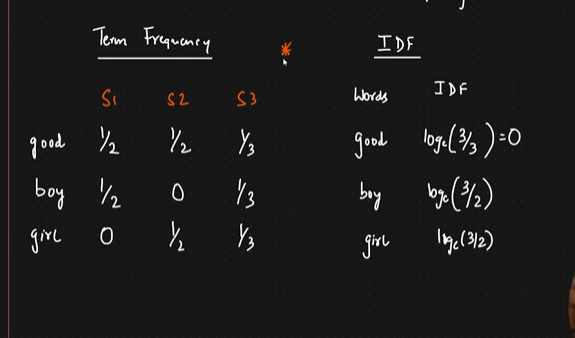

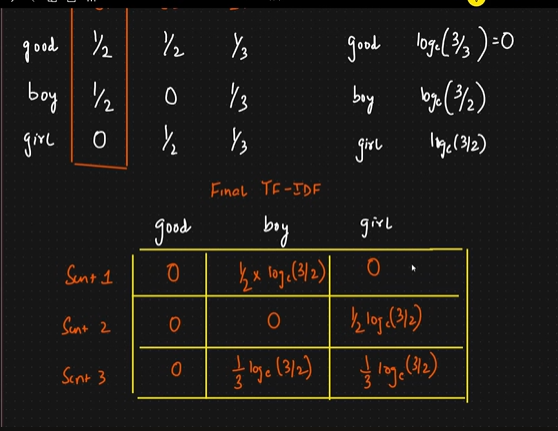

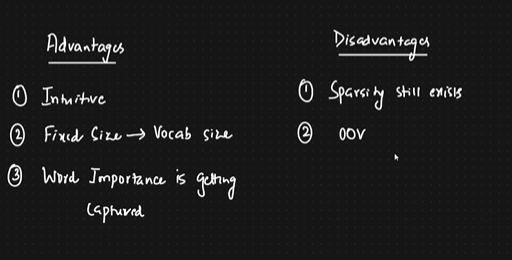

# Word Embeddings 

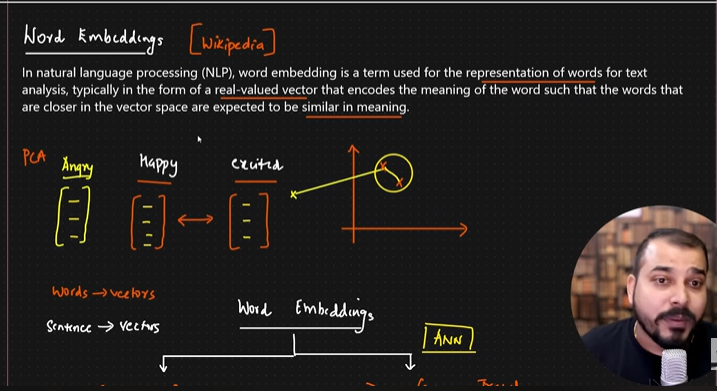

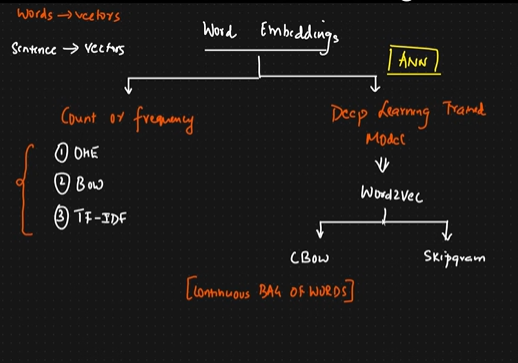


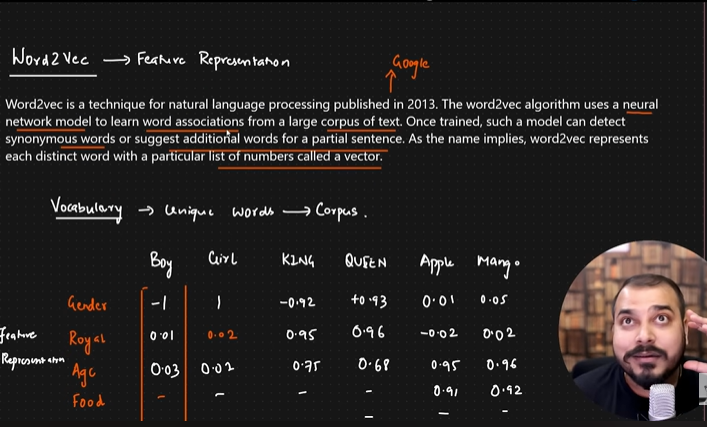

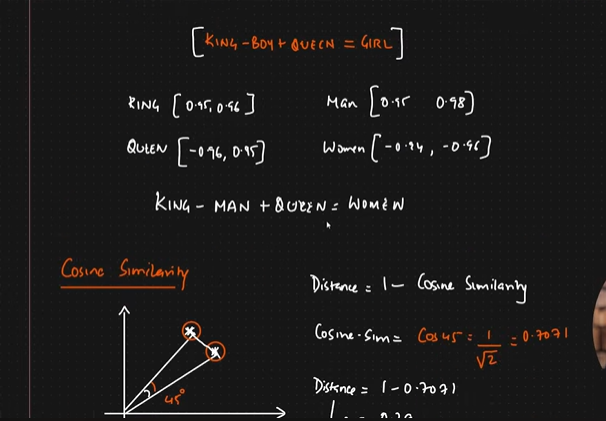
